### **Autores: Daniel Moraleda, Victor Pastor.**

---

<h1 span style="color:#1E90FF; font-weight:bold;">Práctica final FAI: Anonimizador.</span></h1>

<h3 span style="color:orange; font-weight:bold;">1. Introducción a la práctica.</span></h3>
Vivimos en una época en la que las redes sociales, la privacidad y dispositivos electrónicos son una base fundamental del día a día de prácticamente cualquier persona. 
Compartimos nuestros viajes, nuestras comidas, e incluso a personas cercanas que, sin saberlo y por cuenta ajena, ven como su rostro entra en el dataset de la privilegiada empresa a la que elijamos compartir arbitrariamente nuestros datos.  

Nos movemos en un mundo en el que nos arriesgamos a que la gente reconozca donde estamos, que hacemos o nos localicen por fotos usadas por otros.
El anonimato se ha perdido completamente. ¿Qué hago si quiero seguir manteniendo mi privacidad, aunque aparezca en una imagen? 

El objetivo de esta práctica será crear un algoritmo capaz de desenfocar el rostro de una persona en una imagen.  
  
  
<h3 span style="color:orange; font-weight:bold;">2. Funcionamiento del algoritmo.</span></h3> 

Queremos que la herramienta reciba una imagen en la que aparezcan una o varias personas y que esta seleccione las caras de las personas que se encuentren. Tras esto, se le preguntará al usuario cuales son las caras que se quieren anonimizar y se les desenfocará la cara.

<h3 span style="color:orange; font-weight:bold;">3. Baseline y modelo clásico.</span></h3> 

Vamos a tratar de acercarnos o mejorar lo máximo posible un algoritmo clásico del análisis de imagen: el `Haar Cascade`. 
Nuestro modelo base sobre el que trabajaremos para mejorar seguirá esta estructura:

-	Para preprocesar la imagen inicial, convertiremos la imagen de `BGR a HSV` para encontrar en que rango específico de los canales se encuentran los tonos de piel que estamos buscando.

-	Crearemos un umbral para crear una máscara binaria con los tonos de piel seleccionados, de tal forma que lo identificado como piel quede blanco y todo lo demás, negro.

-	Para eliminar el ruido de objetos sueltos e imperfecciones, haremos una erosión y una dilatación (**MorphOpen**) y viceversa (**MorphClose**) y otra dilatación extra para rellenar los huecos de la cara no detectados como piel.

-	Realizaremos una detección de bordes para reconocer la forma del rostro, buscando una forma no muy pequeña con una buena relación ancho – alto (`aspect ratio`) y una buena circularidad.

-	Por último, realizaremos el desenfoque pegando un **desenfoque gaussiano** del rostro sobre la región en la que se encuentra.



---

In [24]:
!pip install opencv-python numpy matplotlib

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Vamos a hacer una primera implementación base para saber la dificultad a la que nos estamos enfrentando. La estructura del siguiente código es exactamente la misma que la del diseño inicial comentado anteriormente. Vamos a ver como funciona.

In [26]:
def anonimizar_rostro(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    resultado = img.copy()
    
    # Conversión a HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Rango de color piel (H: 0-20, S: 48-255, V: 80-255)
    lower_skin = np.array([0, 48, 80], dtype=np.uint8)
    upper_skin = np.array([20, 255, 255], dtype=np.uint8)

    # Máscara inicial
    mask = cv2.inRange(hsv, lower_skin, upper_skin)

    # Operaciones morfológicas
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2) # Erosion + Dilatación para eliminar ruido
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2) # Dilatación para cerrar huecos de las caras
    mask = cv2.dilate(mask, kernel, iterations=1)

    # Detección y filtrado de contornos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    rostros_detectados = 0

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        
        # Filtros (Área, Aspect Ratio, Circularidad)
        area = cv2.contourArea(c)
        # No queremos que el área sea muy pequeña ni muy grande (30% de la imagen)
        imagen_area = img.shape[0] * img.shape[1]
        max_area = 0.3 * imagen_area

        if area < 1000 or area > max_area: 
            continue

        aspect_ratio = float(w) / h
        if aspect_ratio < 0.5 or aspect_ratio > 1.3: continue

        perimeter = cv2.arcLength(c, True)
        if perimeter == 0: continue
        circularity = 4 * np.pi * (area / (perimeter * perimeter))
        if circularity < 0.3: continue

        # Aplicamos desenfoque
        rostros_detectados += 1
        roi = resultado[y:y+h, x:x+w]
        
        # Desenfoque gaussiano fuerte
        roi_blurred = cv2.GaussianBlur(roi, (99, 99), 30)
        resultado[y:y+h, x:x+w] = roi_blurred
        
        # Dibujar rectángulo en la imagen resultado para resaltar la detección
        cv2.rectangle(resultado, (x, y), (x+w, y+h), (0, 255, 0), 2) 

    print(f"Procesamiento terminado. Rostros anonimizados: {rostros_detectados}")
    
    plt.figure(figsize=(15, 5))
    
    # Subplot 1: Imagen Original
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("1. Imagen Original")
    plt.axis('off') # Ocultar ejes X e Y

    # Subplot 2: Máscara 
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray') # Mapa de color gris para binarias
    plt.title("2. Máscara de Piel y Forma")
    plt.axis('off')

    # Subplot 3: Resultado Final
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title("3. Resultado Anonimizado")
    plt.axis('off')

    plt.suptitle(f"Práctica FAI - Detección: {rostros_detectados} rostro(s)")
    plt.tight_layout()
    plt.show()

Procesamiento terminado. Rostros anonimizados: 1


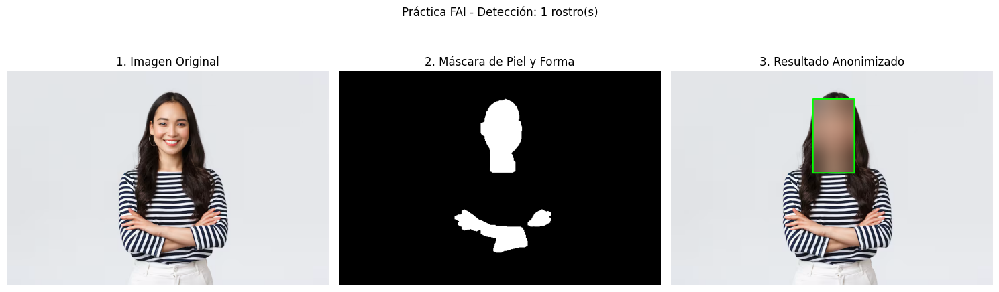

Procesamiento terminado. Rostros anonimizados: 6


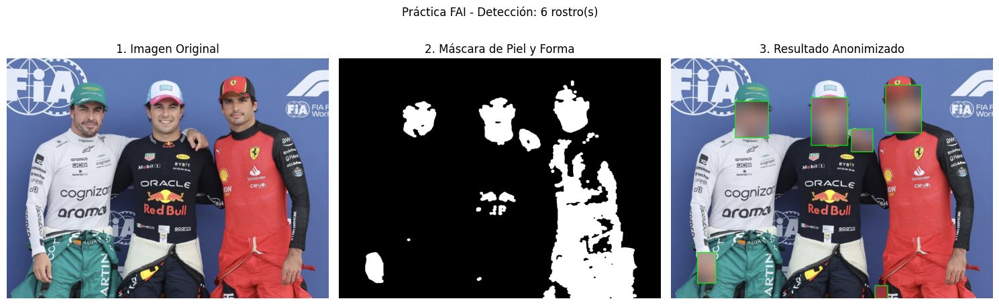

Procesamiento terminado. Rostros anonimizados: 6


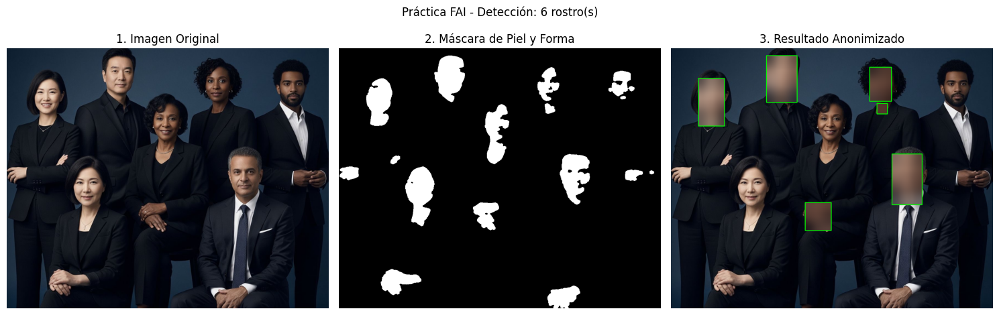

Procesamiento terminado. Rostros anonimizados: 1


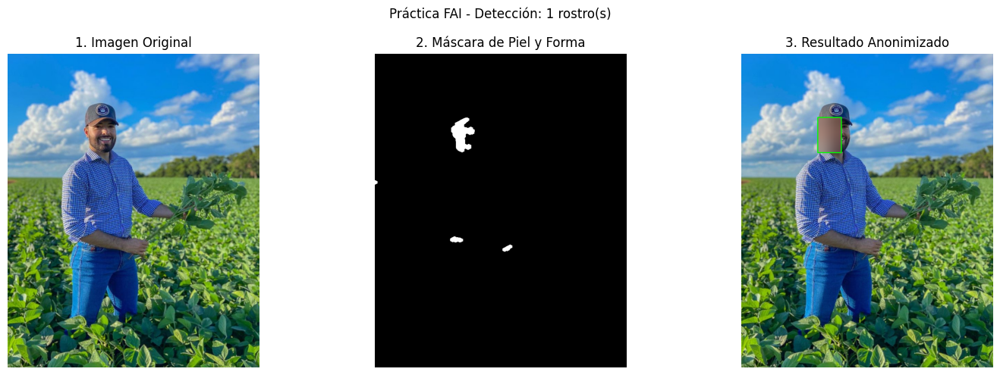

Procesamiento terminado. Rostros anonimizados: 7


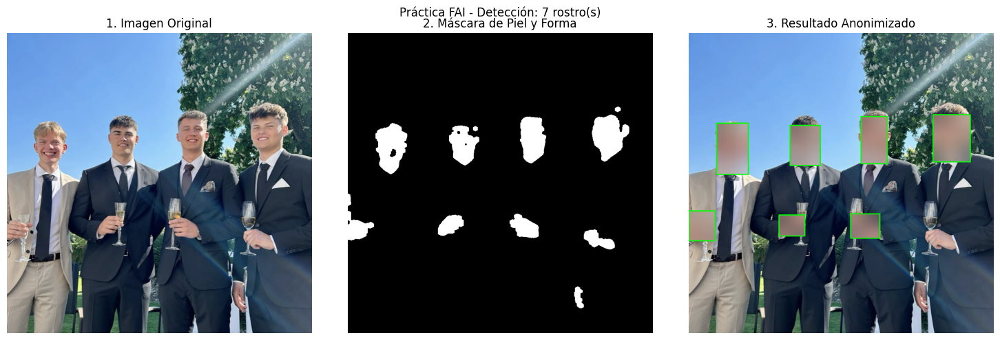

Procesamiento terminado. Rostros anonimizados: 7


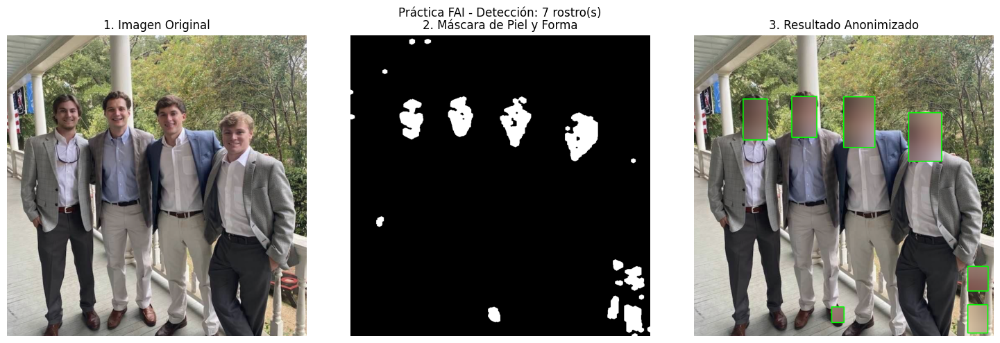

Procesamiento terminado. Rostros anonimizados: 5


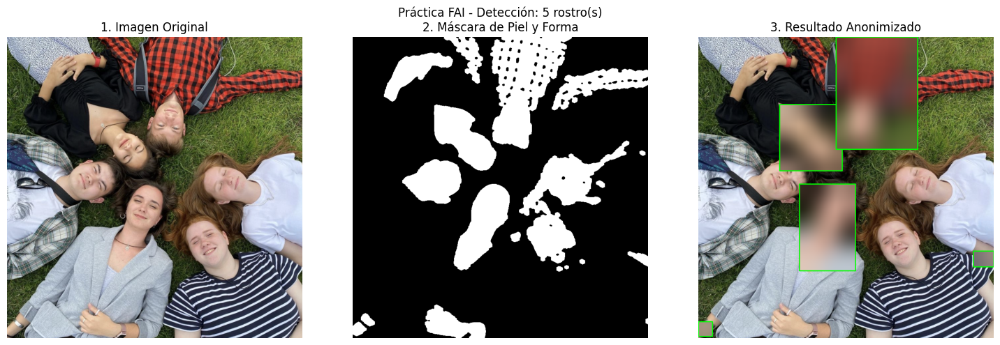

Procesamiento terminado. Rostros anonimizados: 11


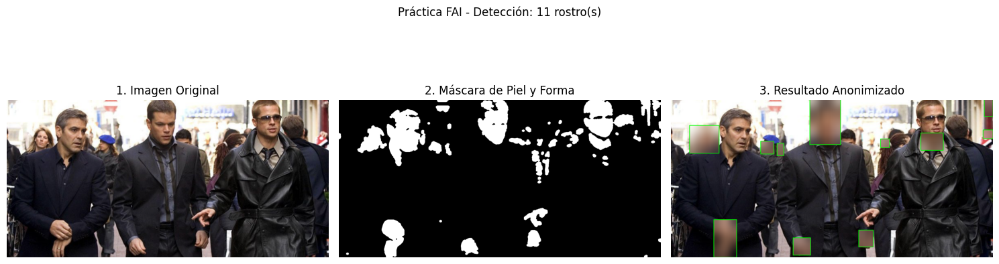

Procesamiento terminado. Rostros anonimizados: 1


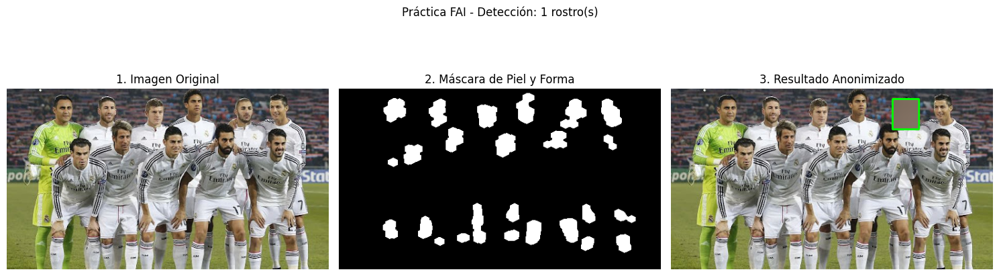

Procesamiento terminado. Rostros anonimizados: 5


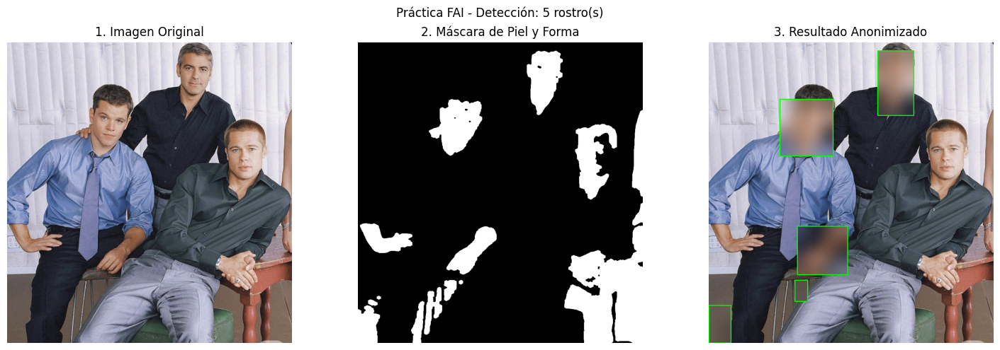

Procesamiento terminado. Rostros anonimizados: 3


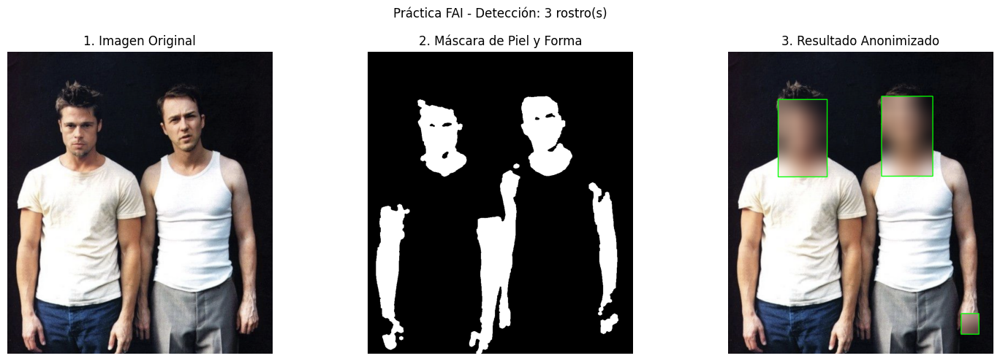

Procesamiento terminado. Rostros anonimizados: 3


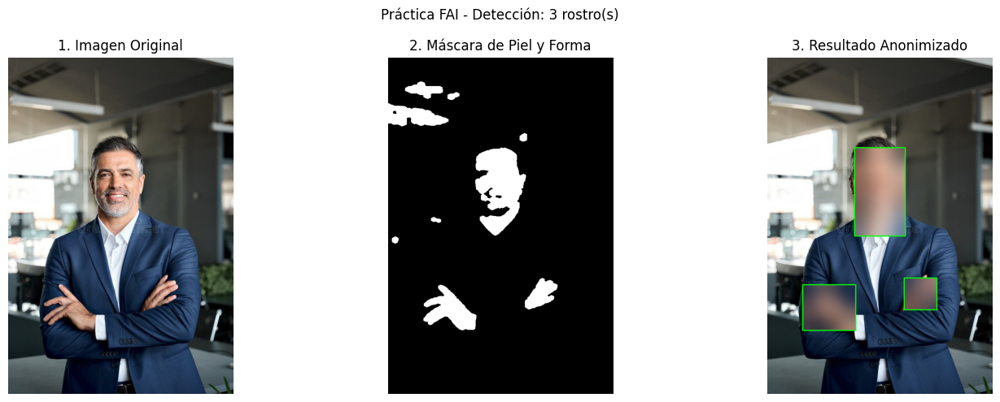

Procesamiento terminado. Rostros anonimizados: 6


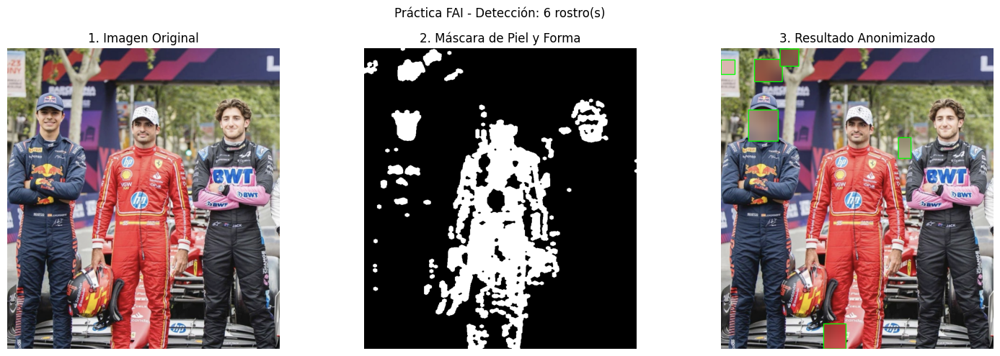

Procesamiento terminado. Rostros anonimizados: 0


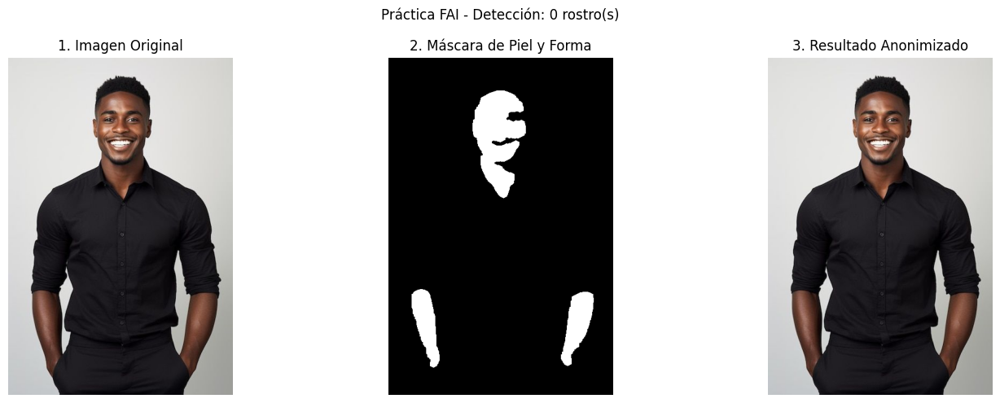

Procesamiento terminado. Rostros anonimizados: 4


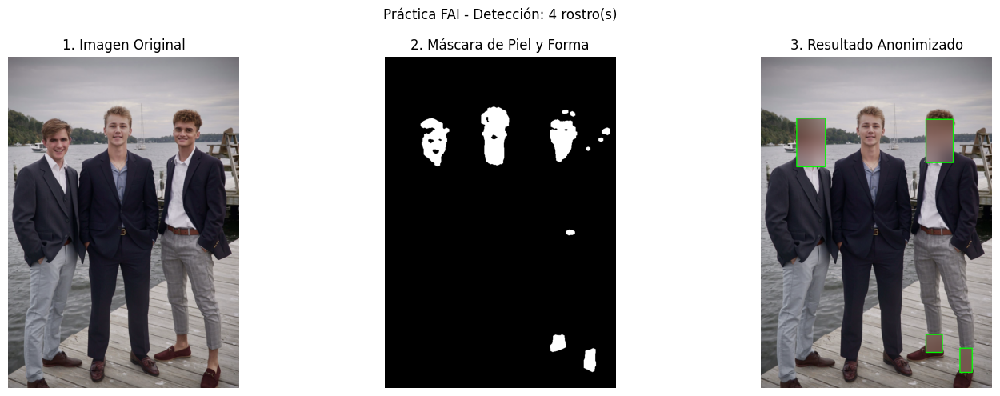

Procesamiento terminado. Rostros anonimizados: 6


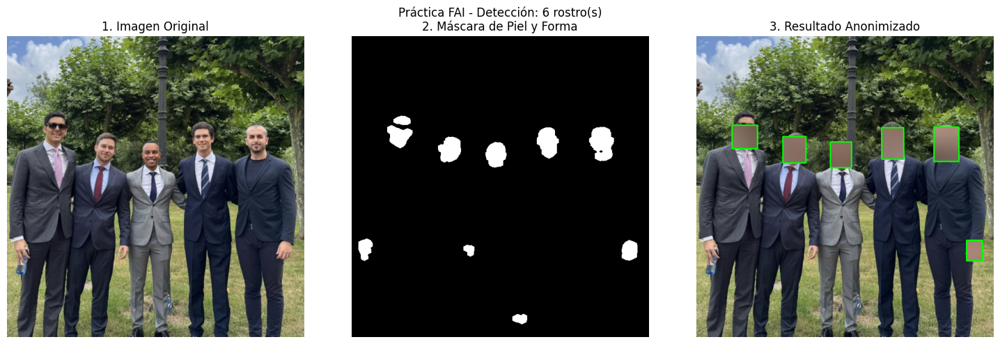

Procesamiento terminado. Rostros anonimizados: 10


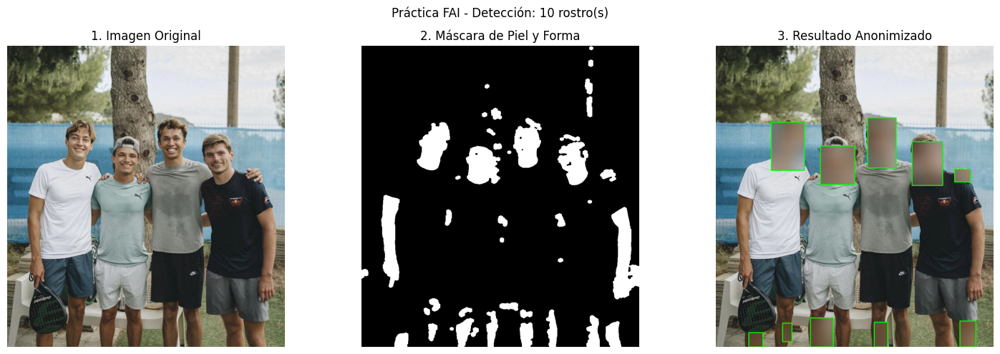

Procesamiento terminado. Rostros anonimizados: 5


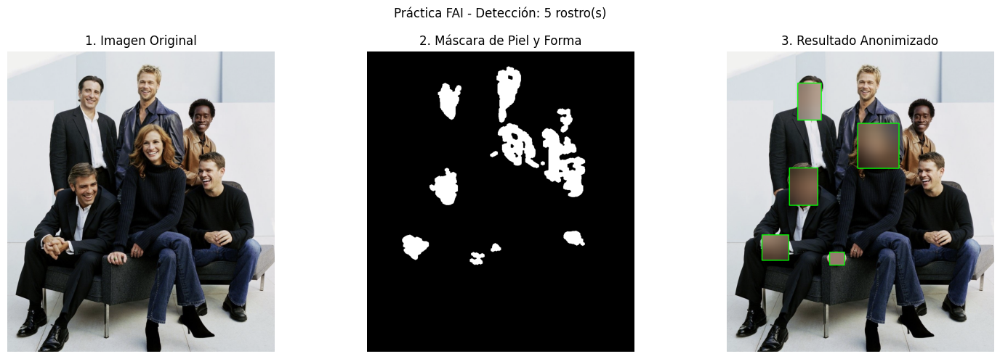

Procesamiento terminado. Rostros anonimizados: 5


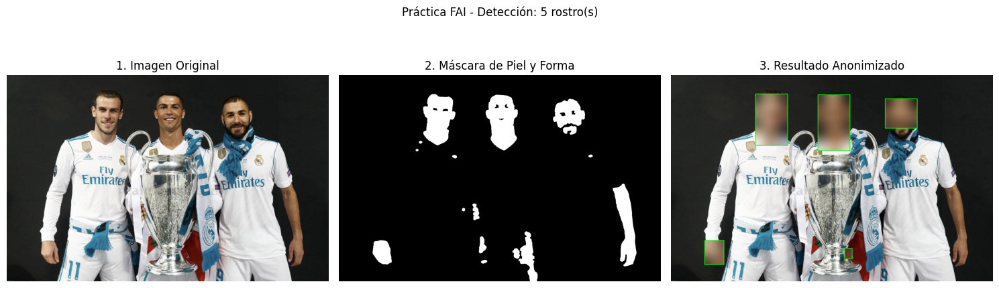

Procesamiento terminado. Rostros anonimizados: 10


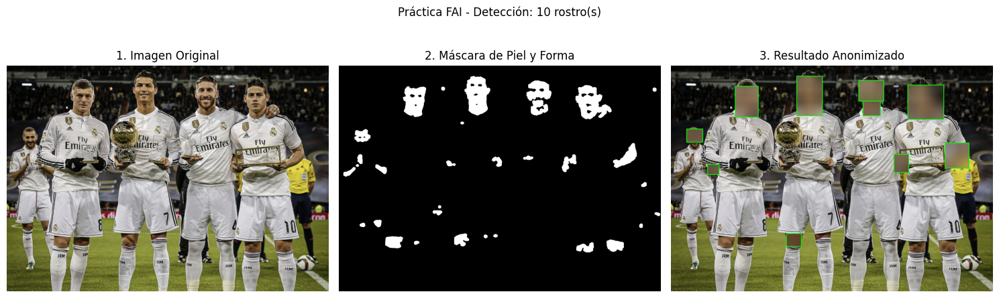

Procesamiento terminado. Rostros anonimizados: 3


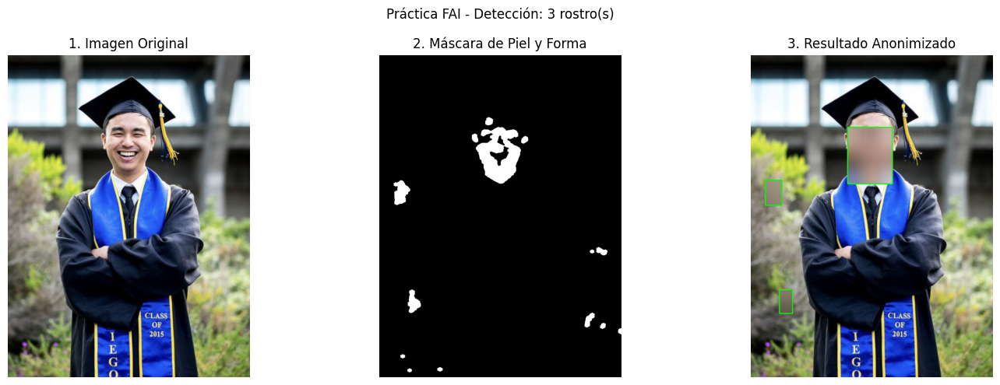

Procesamiento terminado. Rostros anonimizados: 17


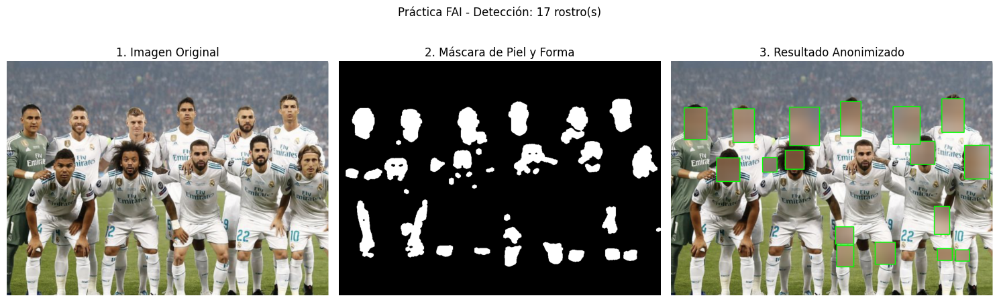

Procesamiento terminado. Rostros anonimizados: 0


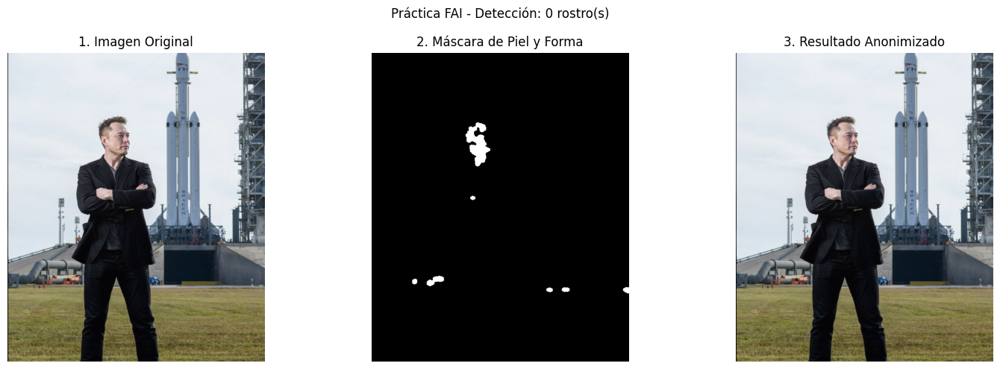

Procesamiento terminado. Rostros anonimizados: 5


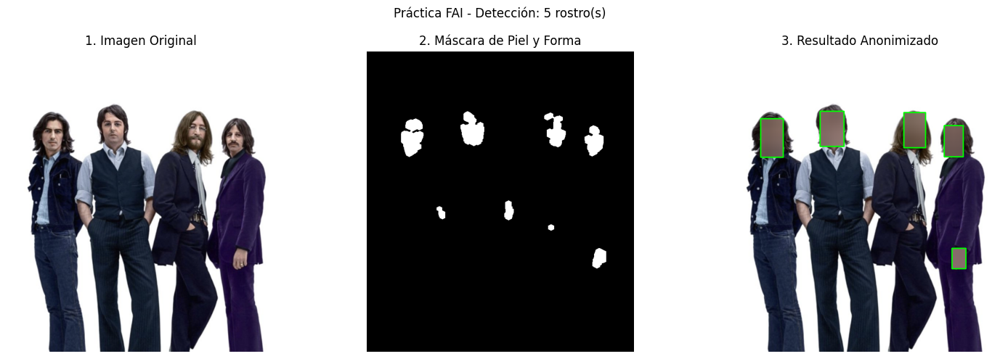

Procesamiento terminado. Rostros anonimizados: 4


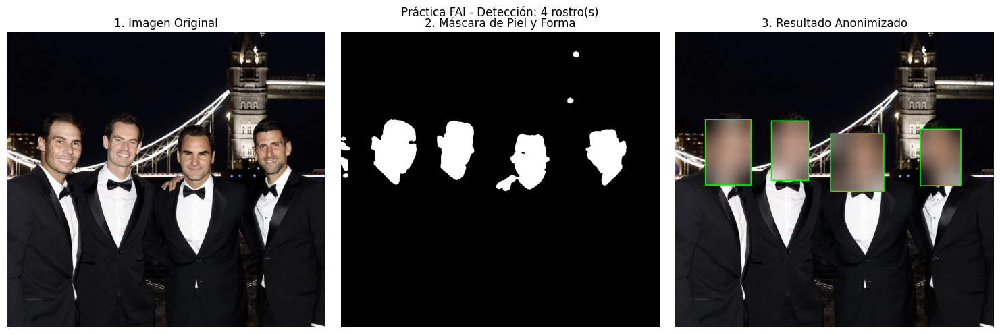

In [27]:
for i in range(1, 26):
    anonimizar_rostro(f'multiple_face/im{i}.png')

Vamos a analizar cuales están siendo los problemas que están sucediendo:
- En primer lugar, el rango de color de HSV está funcionando correctamente. Se están reconociendo todas las caras, al menos parcialmente, por lo que es posible que pueda ajustarse más para encontrar el mejor rango que no deje sin marcar las caras por una mala iluminación o similares. En general, el enfoque inicial es correcto.

- En segundo lugar, las operaciones morfológicas no están consiguiendo rellenar las caras completamente en todos los casos, por lo que se quedan huecos con malos ratios que el algoritmo no clasifica correctamente. Es posible que debamos aumentar las iteraciones de la eliminación de ruido y de el relleno de cara para que funcione mejor.

- En algunas imágenes también estamos viendo como se fusionan unas caras con otras y el algoritmo lo interpreta como un blob gigante. Deberíamos corregir esto usando algoritmos como el de componentes conectadas o la transformada de la distancia.

Con el objetivo de poder compararnos con algún algoritmo ya conocido, vamos a usar como baseline la herramienta `cv2.CascadeClassifier` con los clasificadores del método `Haar Cascade`. Este es uno de los métodos más populares y antiguos para detectar caras sin usar DeepLearning. Las ventajas con las redes de neuronas es que es mucho más rápido, aunque falla mucho más para malos ángulos o iluminaciones.

**Funcionamiento general**:
- El algoritmo busca zonas donde una parte es más oscura que la otra, centrándose en características como que la zona de los ojos suele ser más oscura que la zona de la nariz o la frente.
- Primero, el algoritmo trata de buscar algo que se parezca a una cara en esa zona. Si la respuesta es negativa, se termina el proceso y sino, se empiezan a buscar rasgos faciales que confirmen la hipótesis. Esto es lo que hace que se llame cascada y que sea tan rápido.

Veamos que tal funciona con nuestras imágenes.

In [28]:
def face_detection_cascade(ruta_imagen):
    img = cv2.imread(ruta_imagen)

    # Convertimos a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Cargamos clasificadores Haar pre-entrenados
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    eye_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_eye.xml"
    )

    # Detectar caras
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in faces:
        # Dibujamos rectángulo sobre la cara
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # ROI de la cara para buscar ojos
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = img[y:y + h, x:x + w]

        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(10, 10)
        )

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 0, 255), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Detección de caras y ojos")
    plt.axis("off")
    plt.show()

    return img

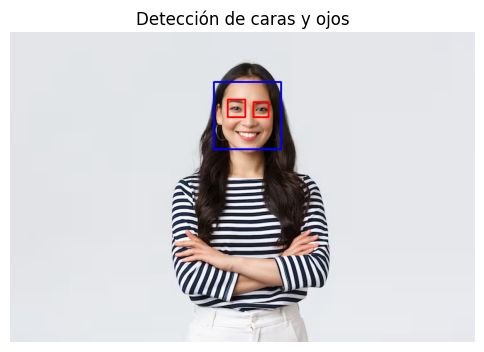

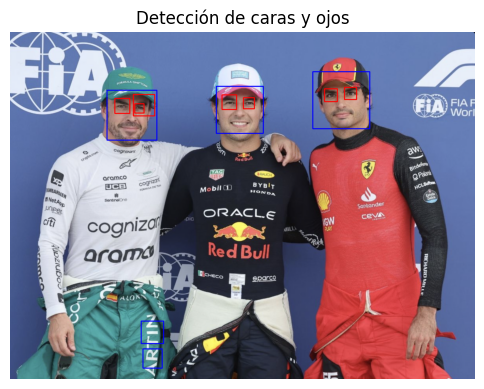

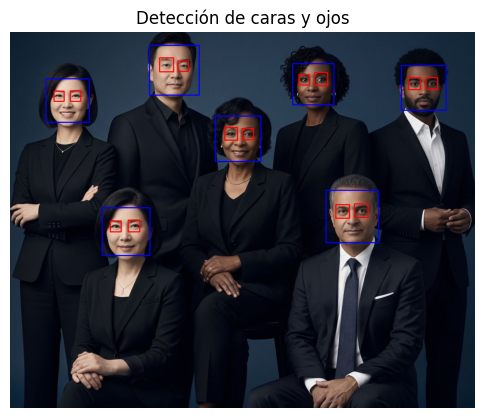

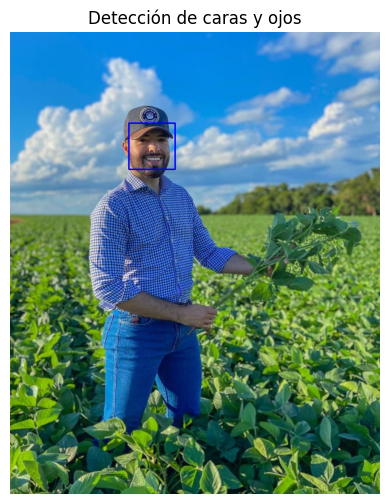

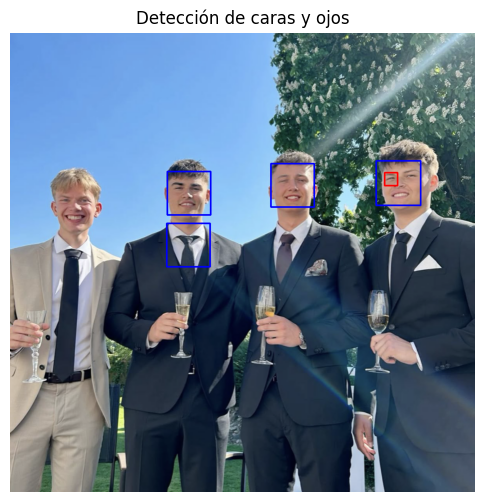

...

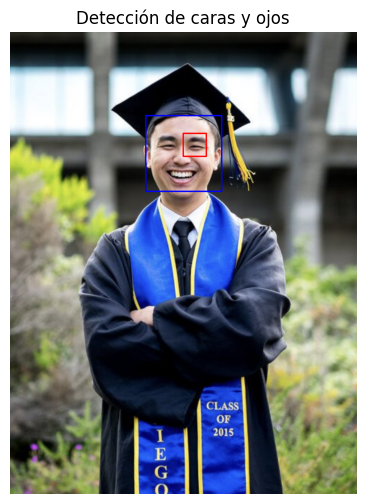

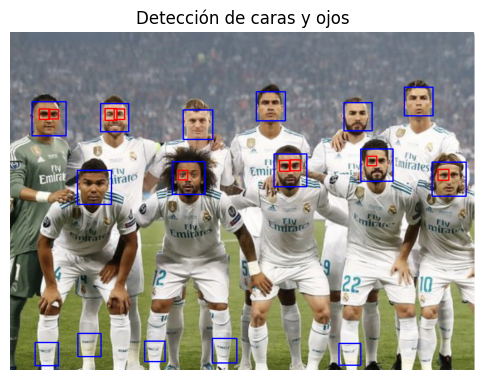

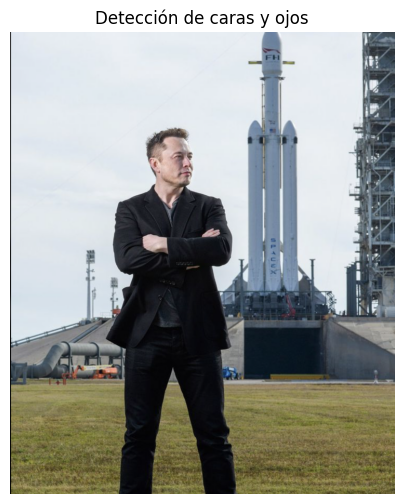

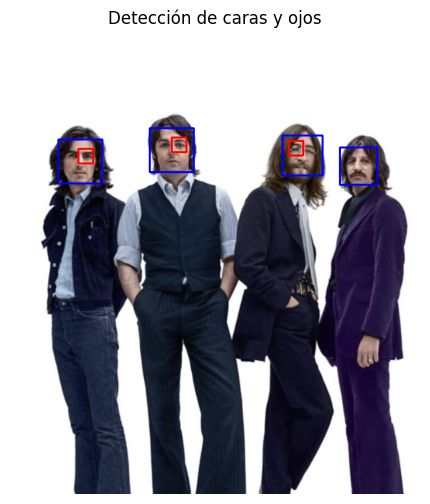

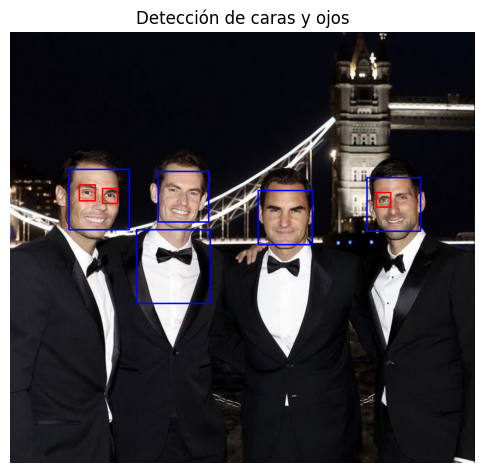

In [29]:
for i in range(1, 26):
    face_detection_cascade(f'multiple_face/im{i}.png')

Como podemos observar, funciona muy bien para caras rectas pero no tan bien para rostros mal enfocados o girados, además de que produce bastantes falsos positivos. Nuestro objetivo será igualar o mejorar estos resultados.

Para no sobrecargar este archivo con las imágenes, desarrollaremos los nuevos modelos en diferentes notebooks, siendo el primero de ellos `selector1.ipynb`.